In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\Financial_Transaction_Analytics\data\feature_engineered_data\transactions_feature_engineered.csv")

In [3]:
df.head()

,transaction_datetime,transaction_id,transaction_unix_time,credit_card_number,customer_name,customer_gender,date_of_birth,customer_job,customer_street,customer_city,...,transaction_month_name,transaction_day,transaction_day_name,transaction_hour,time_of_day,weekend,customer_age,customer_age_group,transaction_amount_group,city_population_group
0,2019-01-01 00:00:18,0b242abb623afc578575680df30655b9,1325376018,2703186189652095,Jennifer Banks,F,1988-03-09,"Psychologist, counselling",561 Perry Cove,Moravian Falls,...,January,1,Tuesday,0,Night,weekdays,30,18-35,Low,Small Town
1,2019-01-01 00:00:44,1f76529f8574734946361c461b024d99,1325376044,630423337322,Stephanie Gill,F,1978-06-21,Special educational needs teacher,43039 Riley Greens Suite 393,Orient,...,January,1,Tuesday,0,Night,weekdays,40,35-50,Medium,Small Town
2,2019-01-01 00:00:51,a1a22d70485983eac12b5b88dad1cf95,1325376051,38859492057661,Edward Sanchez,M,1962-01-19,Nature conservation officer,594 White Dale Suite 530,Malad City,...,January,1,Tuesday,0,Night,weekdays,56,50-65,High,Small Town
3,2019-01-01 00:01:16,6b849c168bdad6f867558c3793159a81,1325376076,3534093764340240,Jeremy White,M,1967-01-12,Patent attorney,9443 Cynthia Court Apt. 038,Boulder,...,January,1,Tuesday,0,Night,weekdays,51,50-65,Low,Small Town
4,2019-01-01 00:03:06,a41d7549acf90789359a9aa5346dcb46,1325376186,375534208663984,Tyler Garcia,M,1986-03-28,Dance movement psychotherapist,408 Bradley Rest,Doe Hill,...,January,1,Tuesday,0,Night,weekdays,32,18-35,Low,Small Town


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 33 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_datetime      1296675 non-null  str    
 1   transaction_id            1296675 non-null  str    
 2   transaction_unix_time     1296675 non-null  int64  
 3   credit_card_number        1296675 non-null  int64  
 4   customer_name             1296675 non-null  str    
 5   customer_gender           1296675 non-null  str    
 6   date_of_birth             1296675 non-null  str    
 7   customer_job              1296675 non-null  str    
 8   customer_street           1296675 non-null  str    
 9   customer_city             1296675 non-null  str    
 10  customer_state            1296675 non-null  str    
 11  customer_zip              1296675 non-null  int64  
 12  customer_latitude         1296675 non-null  float64
 13  customer_longitude        1296675 non-

In [5]:
df.describe()

,transaction_unix_time,credit_card_number,customer_zip,customer_latitude,customer_longitude,city_population,merchant_latitude,merchant_longitude,transaction_amount,fraud_flag,transaction_year,transaction_month,transaction_day,transaction_hour,customer_age
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,1.349244e+09,4.171920e+17,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,3.853734e+01,-9.022646e+01,7.035104e+01,5.788652e-03,2.019287e+03,6.142150e+00,1.558798e+01,1.280486e+01,4.549648e+01
std,1.284128e+07,1.308806e+18,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,5.109788e+00,1.377109e+01,1.603160e+02,7.586269e-02,4.522452e-01,3.417703e+00,8.829121e+00,6.817824e+00,1.739692e+01
min,1.325376e+09,6.041621e+10,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.902779e+01,-1.666712e+02,1.000000e+00,0.000000e+00,2.019000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.300000e+01
25%,1.338751e+09,1.800429e+14,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,3.473357e+01,-9.689728e+01,9.650000e+00,0.000000e+00,2.019000e+03,3.000000e+00,8.000000e+00,7.000000e+00,3.200000e+01
50%,1.349250e+09,3.521417e+15,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,3.936568e+01,-8.743839e+01,4.752000e+01,0.000000e+00,2.019000e+03,6.000000e+00,1.500000e+01,1.400000e+01,4.300000e+01
75%,1.359385e+09,4.642255e+15,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,4.195716e+01,-8.023680e+01,8.314000e+01,0.000000e+00,2.020000e+03,9.000000e+00,2.300000e+01,1.900000e+01,5.700000e+01
max,1.371817e+09,4.992346e+18,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,2.894890e+04,1.000000e+00,2.020000e+03,1.200000e+01,3.100000e+01,2.300000e+01,9.500000e+01


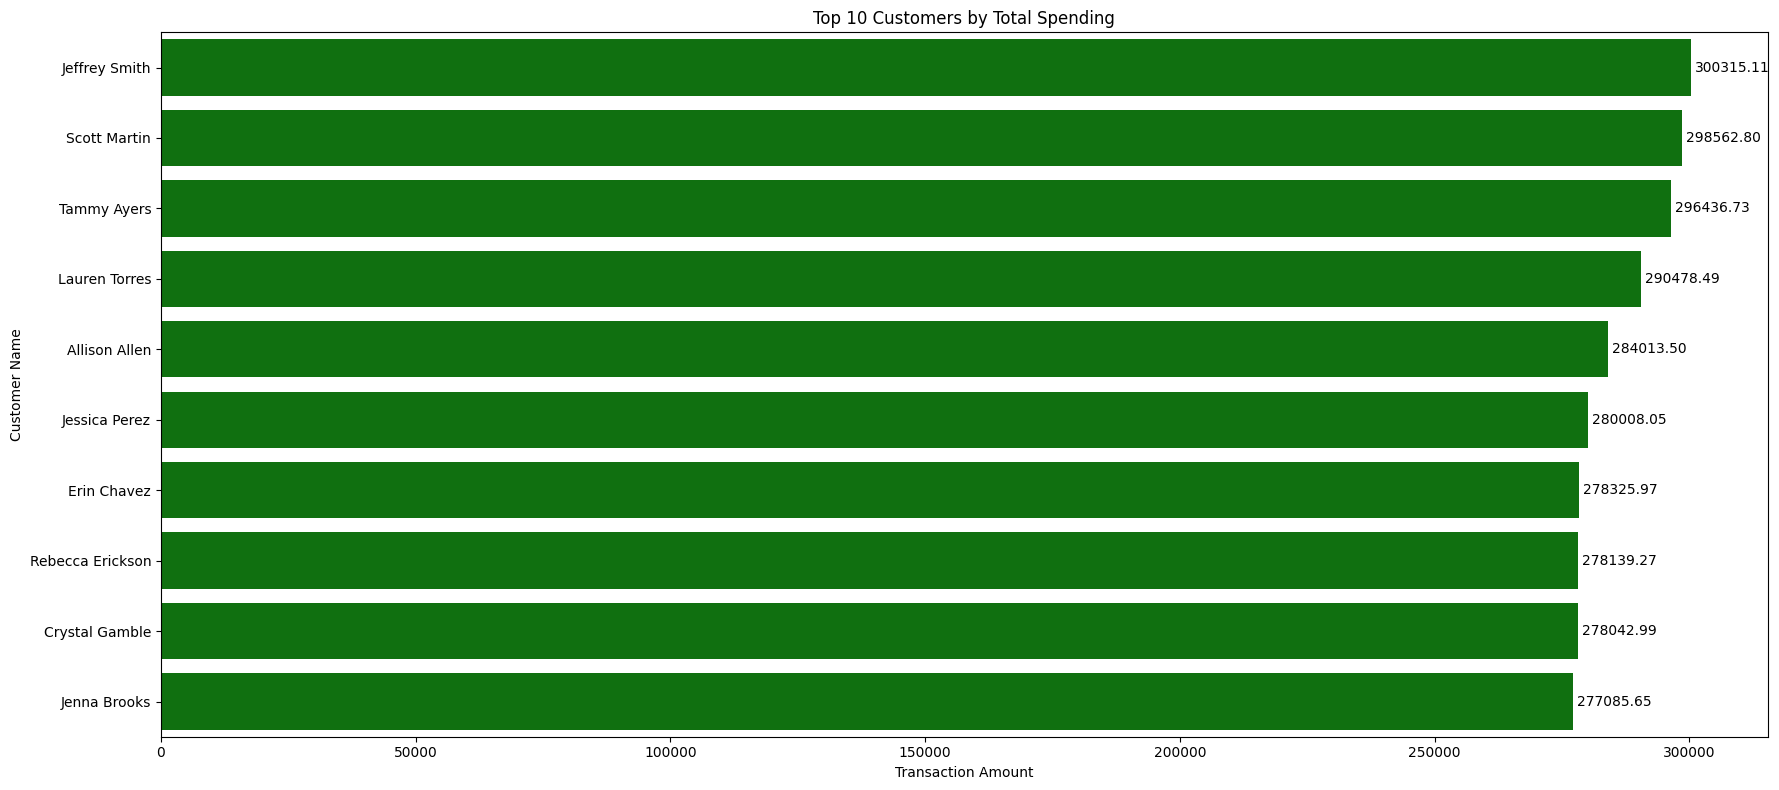

In [152]:
highest_customer_spending = (
    df.groupby ("customer_name")["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount", ascending = False)
      .head(10)
)

plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_customer_spending,
            x = "transaction_amount",
            y = "customer_name",
            color="green")
for container in ax.containers:
        ax.bar_label(
        container,
        fmt="%.2f",
        padding=3)
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Transaction Amount")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

Business Insight:

A small group of customers contributes exceptionally high transaction value, with Jeffrey Smith leading at over 300K in total spending. The spending difference among the top 10 customers is relatively small, suggesting that these customers have similar purchasing power and represent the business's highest-value customer segment. Retaining and rewarding these customers through loyalty programs or personalized offers could have a significant impact on overall revenue.

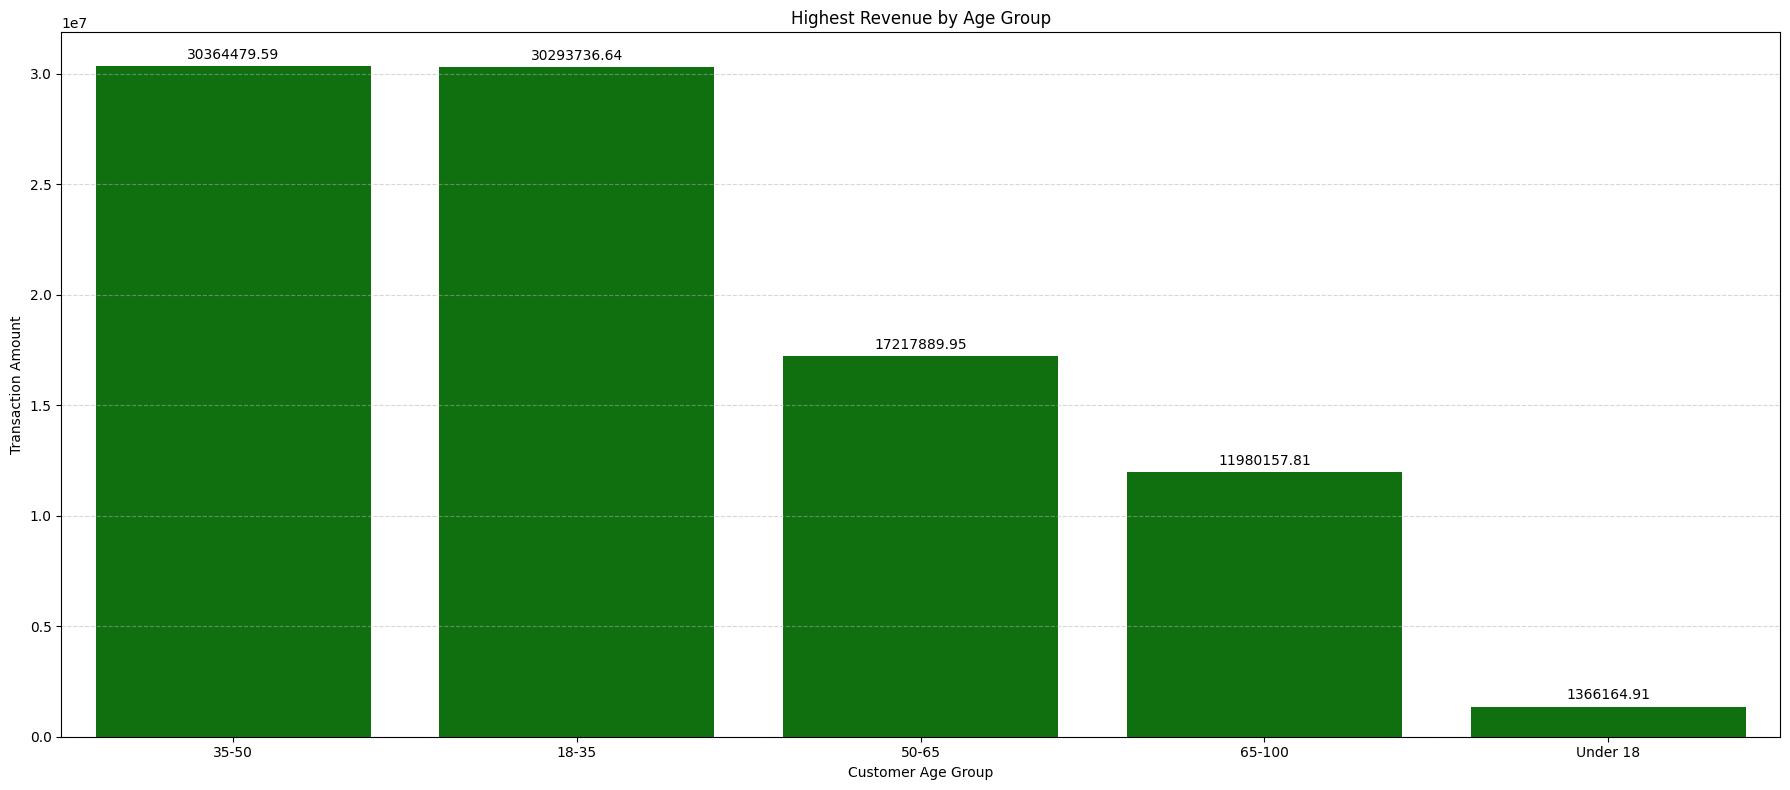

In [153]:
highest_revenue_by_age_group = (
    df.groupby("customer_age_group")["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount", ascending = False)
)
plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_revenue_by_age_group,
                 x = "customer_age_group",
                 y = "transaction_amount",
                 color = "green")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt ="%.2f",
        padding = 3)
plt.title("Highest Revenue by Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Transaction Amount")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Customers aged 18–35 and 35–50 are the primary revenue drivers, each contributing over $30 million, together accounting for the majority of total revenue. This suggests these age groups should remain the main focus for marketing, loyalty programs, and personalized offers.

Revenue drops significantly after age 50, while customers under 18 contribute only a very small share of total revenue, indicating they have minimal purchasing power or transaction activity in this dataset.

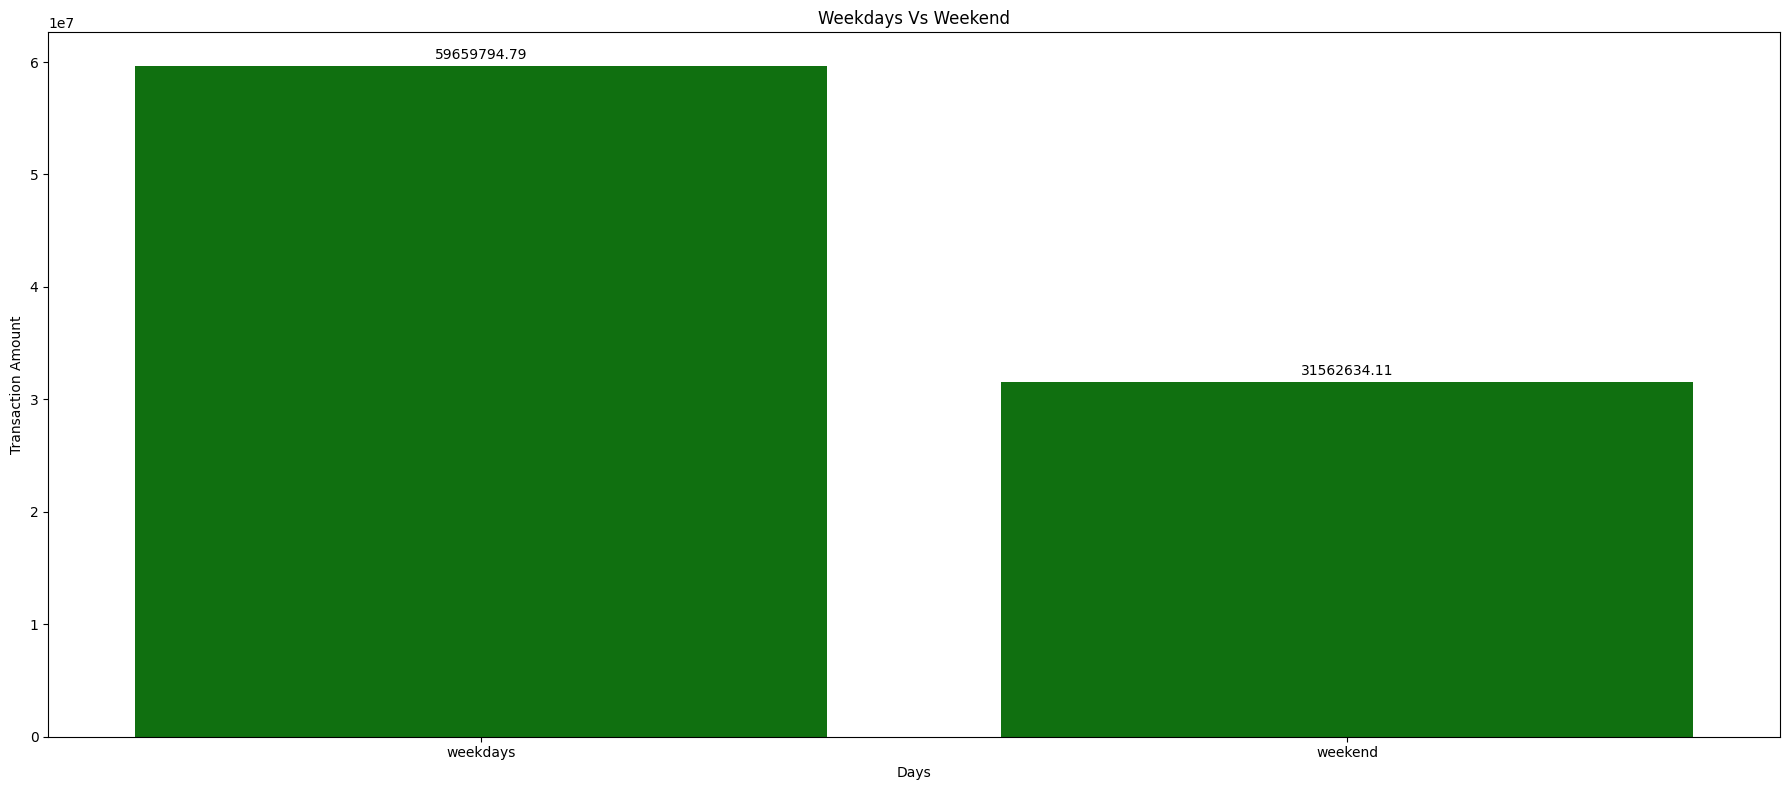

In [39]:
weekend_vs_weekday = (
    df.groupby("weekend")["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount", ascending = False)
)
plt.figure(figsize=(18,8))
ax = sns.barplot(data = weekend_vs_weekday,
                 x = "weekend",
                 y = "transaction_amount",
                 color = "green")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.2f",
        padding = 3)
plt.title("Weekdays Vs Weekend")
plt.xlabel("Days")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

Business Insight:

Weekdays generate significantly higher revenue than weekends, contributing about $59.66 million, compared to $31.56 million on weekends.

This indicates that customers are more active and spend considerably more during weekdays, likely due to routine purchases such as groceries, fuel, commuting, and other daily expenses.

Weekend spending is lower, suggesting customers either make fewer purchases or spend less per transaction.

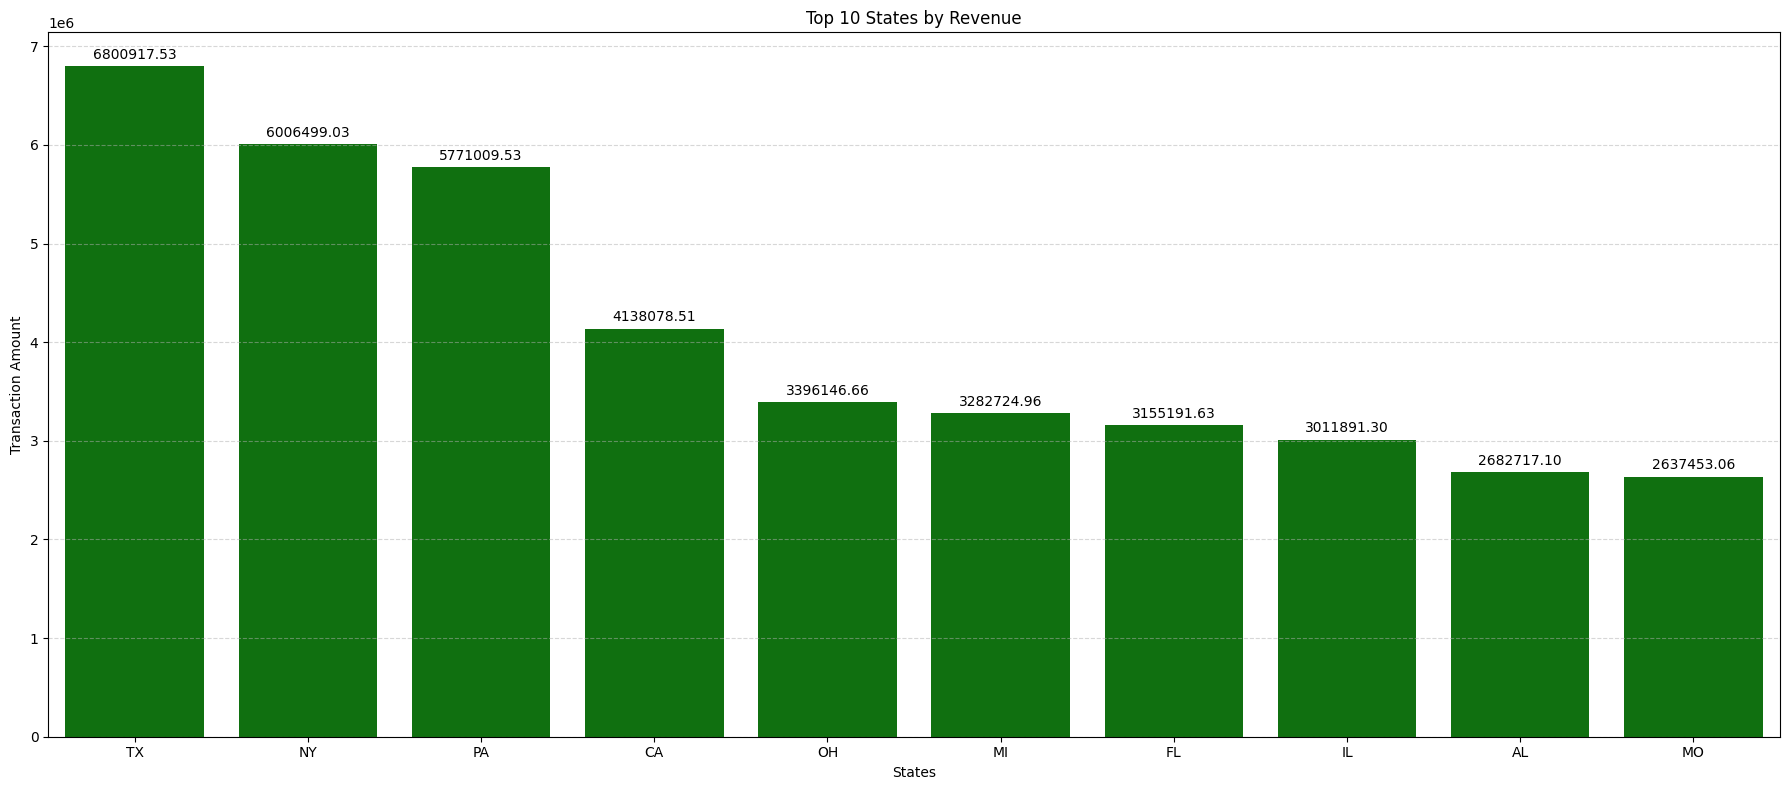

In [154]:
highest_revenue_by_state = (
    df.groupby("customer_state")["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount", ascending = False)
      .head(10)
)
plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_revenue_by_state,
                 x = "customer_state",
                 y = "transaction_amount",
                 color = "green")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.2f",
        padding = 3)
plt.title("Top 10 States by Revenue")
plt.xlabel("States")
plt.ylabel("Transaction Amount")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Your chart clearly shows that Texas (TX) is the highest revenue-generating state, contributing about $6.8 million in transaction revenue. New York (NY) and Pennsylvania (PA) follow closely with around $6.0 million and $5.8 million, while California (CA) ranks fourth with approximately $4.1 million. The remaining states generate noticeably lower revenue, indicating that a small number of states contribute a large share of total business revenue. This suggests that the company should continue strengthening customer engagement and retention in these high-performing states while exploring opportunities to increase sales in lower-performing regions through targeted marketing and promotional campaigns.

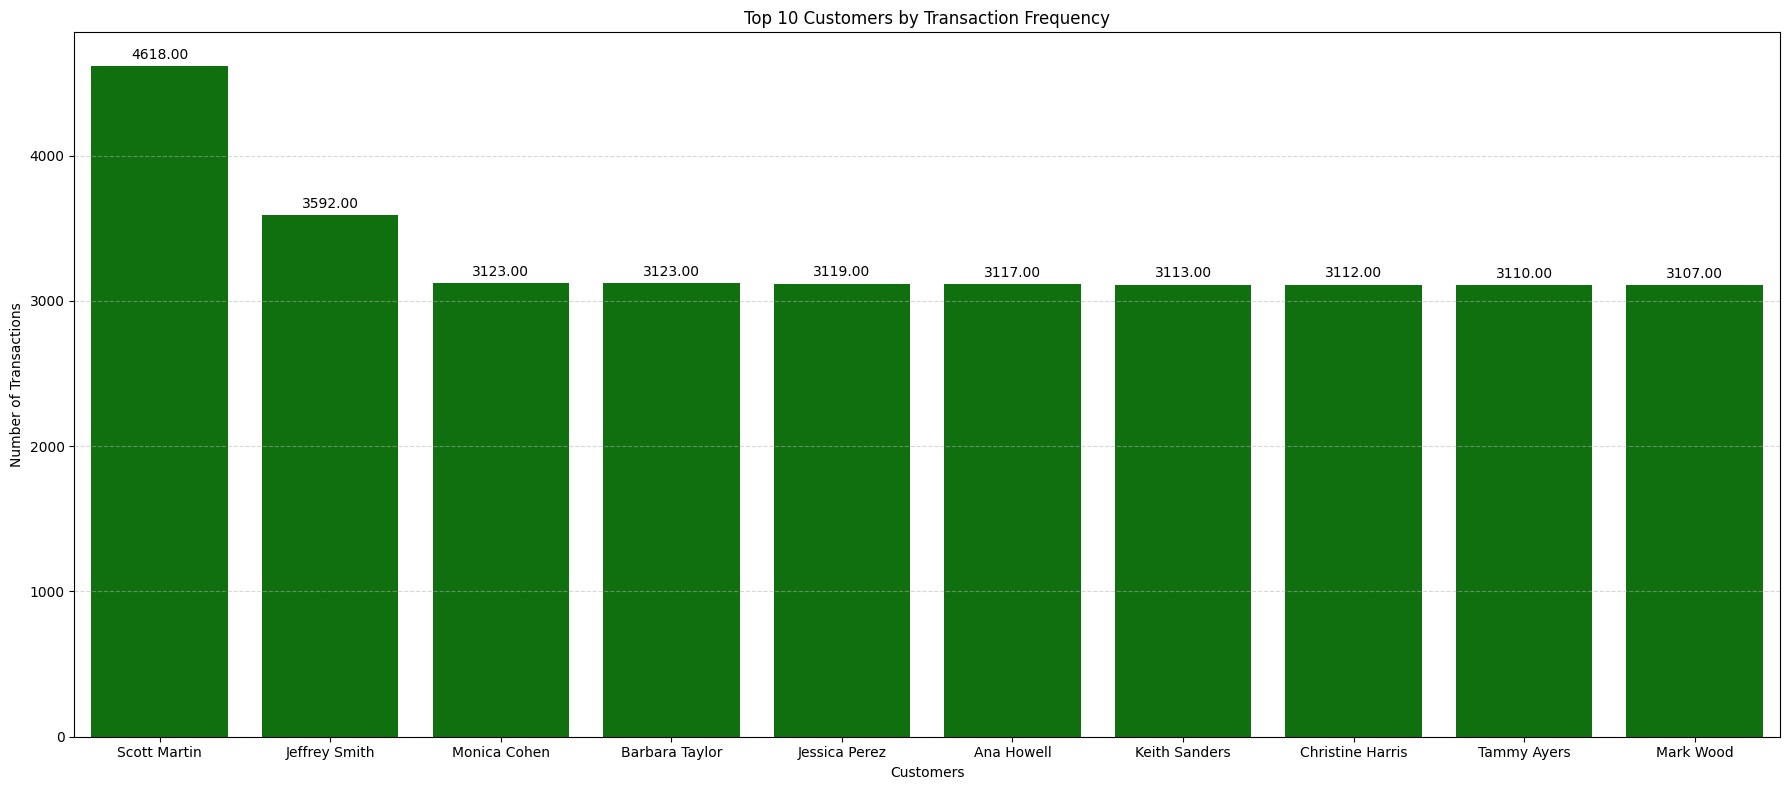

In [155]:
highest_transaction_frequency = (
    df.groupby("customer_name")["transaction_amount"]
      .count()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount", ascending = False)
      .head(10)
)
plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_transaction_frequency,
                 x = "customer_name",
                 y = "transaction_amount",
                 color = "green")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.2f",
        padding = 3)
plt.title("Top 10 Customers by Transaction Frequency")
plt.xlabel("Customers")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Scott Martin is the most active customer with 4,618 transactions, followed by Jeffrey Smith with 3,592 transactions. The remaining top customers have very similar transaction counts (around 3,100), indicating a loyal group of frequent customers. These customers are ideal candidates for loyalty rewards, personalized offers, and retention campaigns.

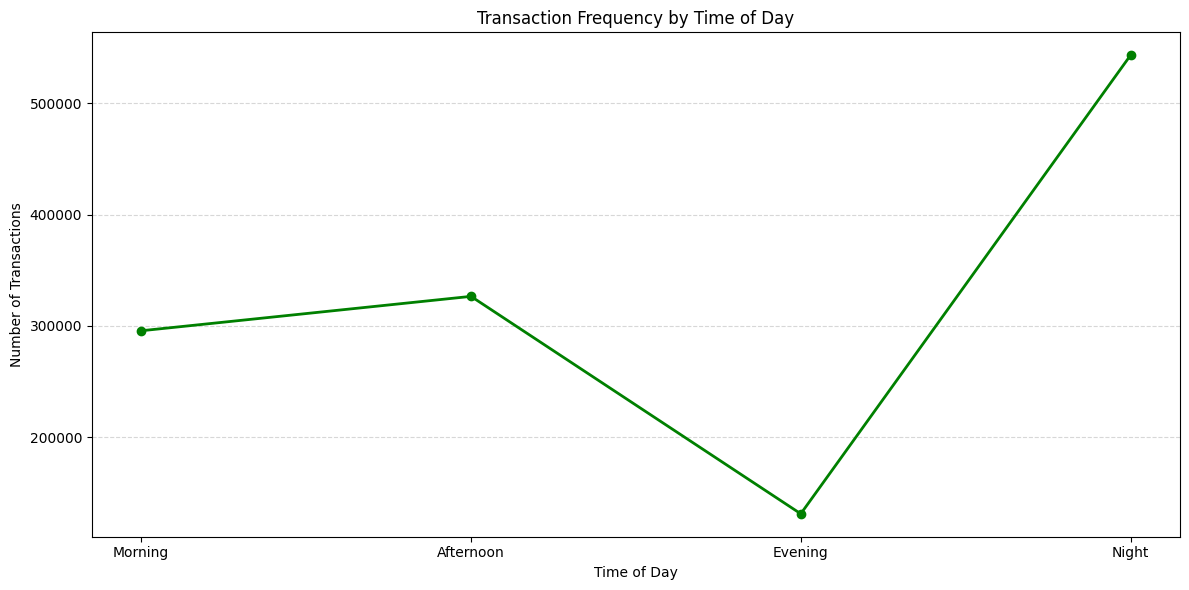

In [156]:
highest_transaction_frequency = (
    df.groupby("time_of_day")["transaction_amount"]
      .count()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount", ascending = False)
)
order = ["Morning", "Afternoon", "Evening", "Night"]
highest_transaction_frequency["time_of_day"] = pd.Categorical(highest_transaction_frequency['time_of_day'],categories = order,ordered = True)

highest_transaction_frequency = highest_transaction_frequency.sort_values("time_of_day")

plt.figure(figsize=(12,6))
plt.plot(
    highest_transaction_frequency["time_of_day"],
    highest_transaction_frequency["transaction_amount"],
    marker="o",
    linewidth=2,
    color = "green"
)

plt.title("Transaction Frequency by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Transaction activity gradually increases from Morning to Afternoon, drops significantly during the Evening, and then peaks sharply at Night, making Night the busiest transaction period. This suggests businesses should allocate more resources and monitoring during nighttime hours, while the lower evening activity presents a good opportunity for targeted promotions to boost engagement.

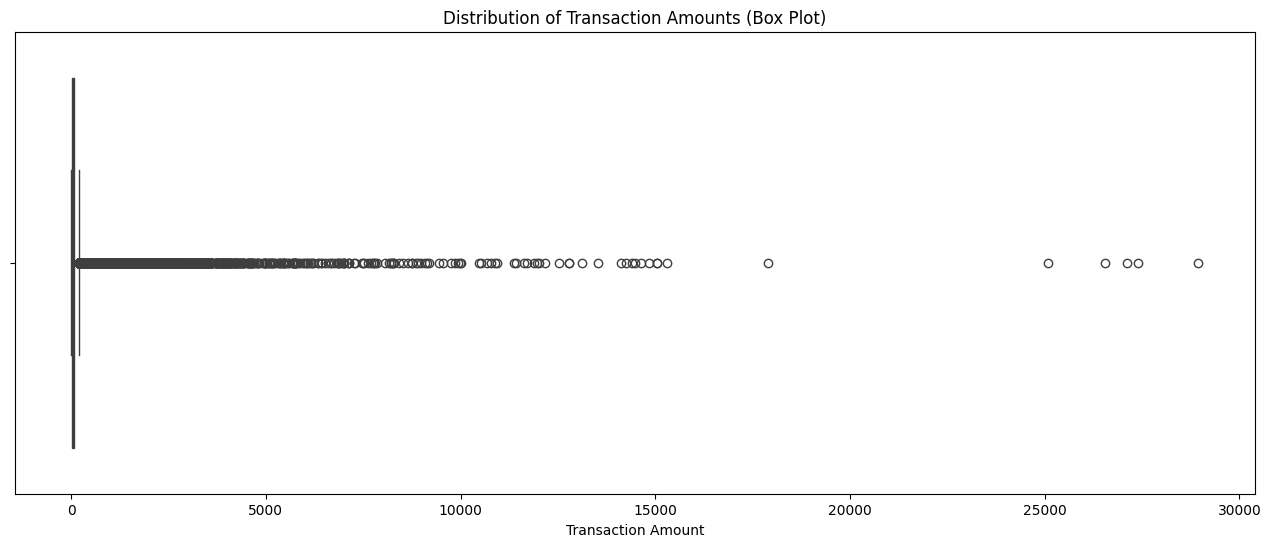

In [73]:
plt.figure(figsize=(16,6))

sns.boxplot(
    x=df["transaction_amount"]
)
plt.title("Distribution of Transaction Amounts (Box Plot)")
plt.xlabel("Transaction Amount")
plt.show()

Business insight:

Most customer transactions are of relatively low value, while a small number of exceptionally large transactions contribute disproportionately to the overall transaction range. This indicates a highly right-skewed distribution, suggesting that revenue is driven by a limited number of high-value purchases.

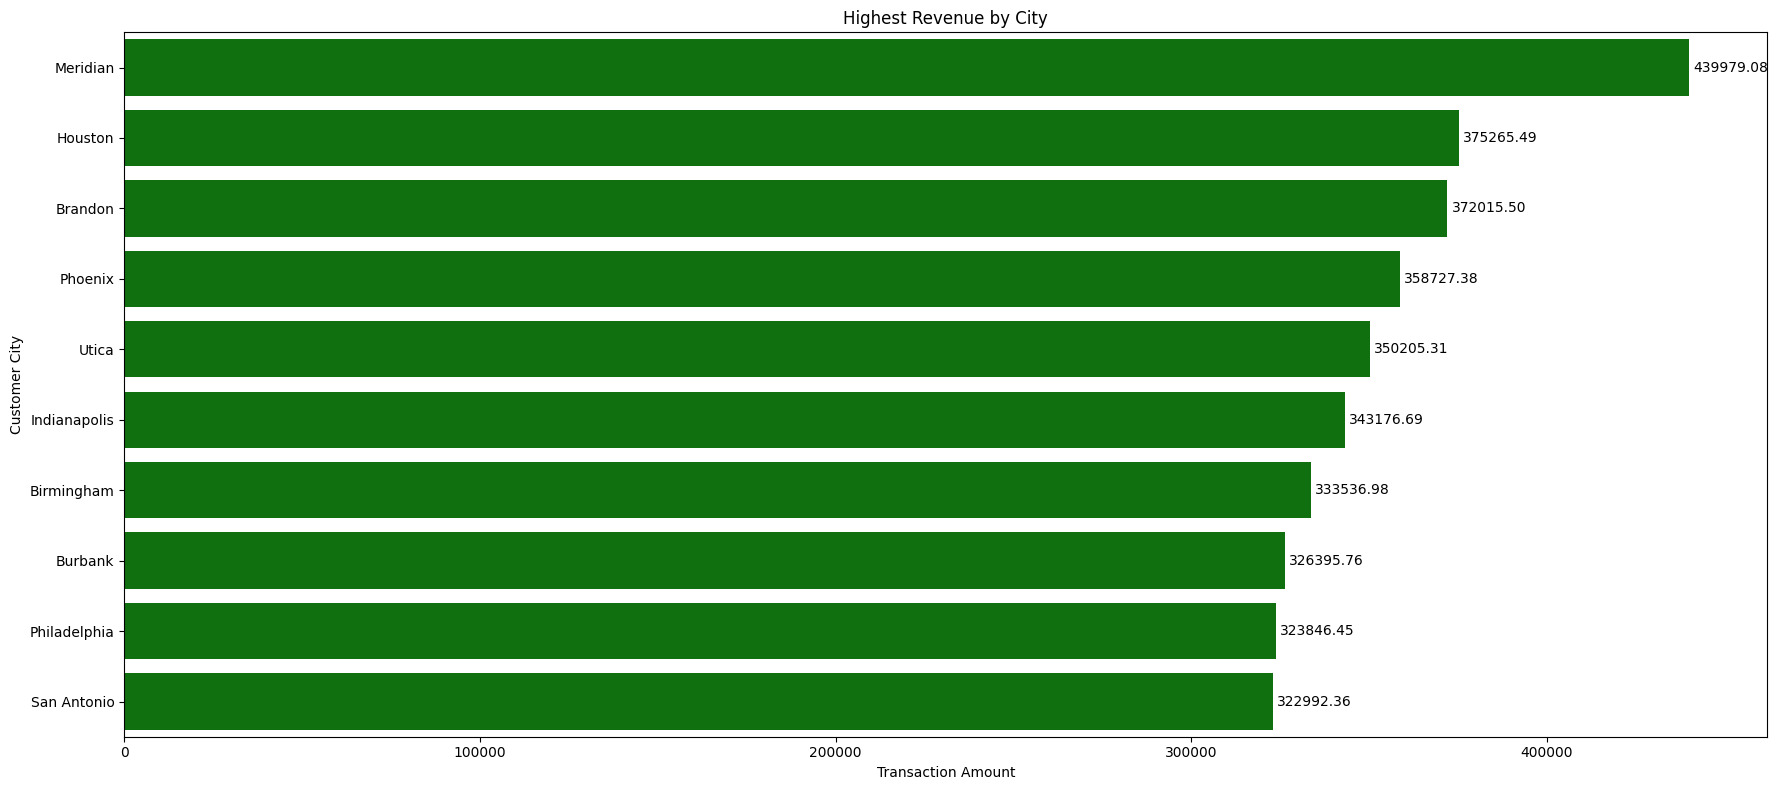

In [159]:
highest_revenue_by_city = (
    df.groupby("customer_city")["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount",ascending = False)
      .head(10)
)
plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_revenue_by_city,
                 x = "transaction_amount",
                 y = "customer_city",
                 color = "green")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.2f",
        padding = 3
    )
plt.title("Highest Revenue by City")
plt.xlabel("Transaction Amount")
plt.ylabel("Customer City")
plt.tight_layout()
plt.show()

Business Insight:

Meridian is the highest-revenue city with approximately $439,979, followed by Houston with $375,265 and Brandon with $372,016. The remaining top cities generate relatively similar revenue, ranging from around $323K to $359K, indicating a strong group of high-performing markets. These cities are ideal targets for market expansion, customer acquisition, and focused sales and marketing campaigns, while Meridian can be further analyzed to identify the factors driving its stronger performance.

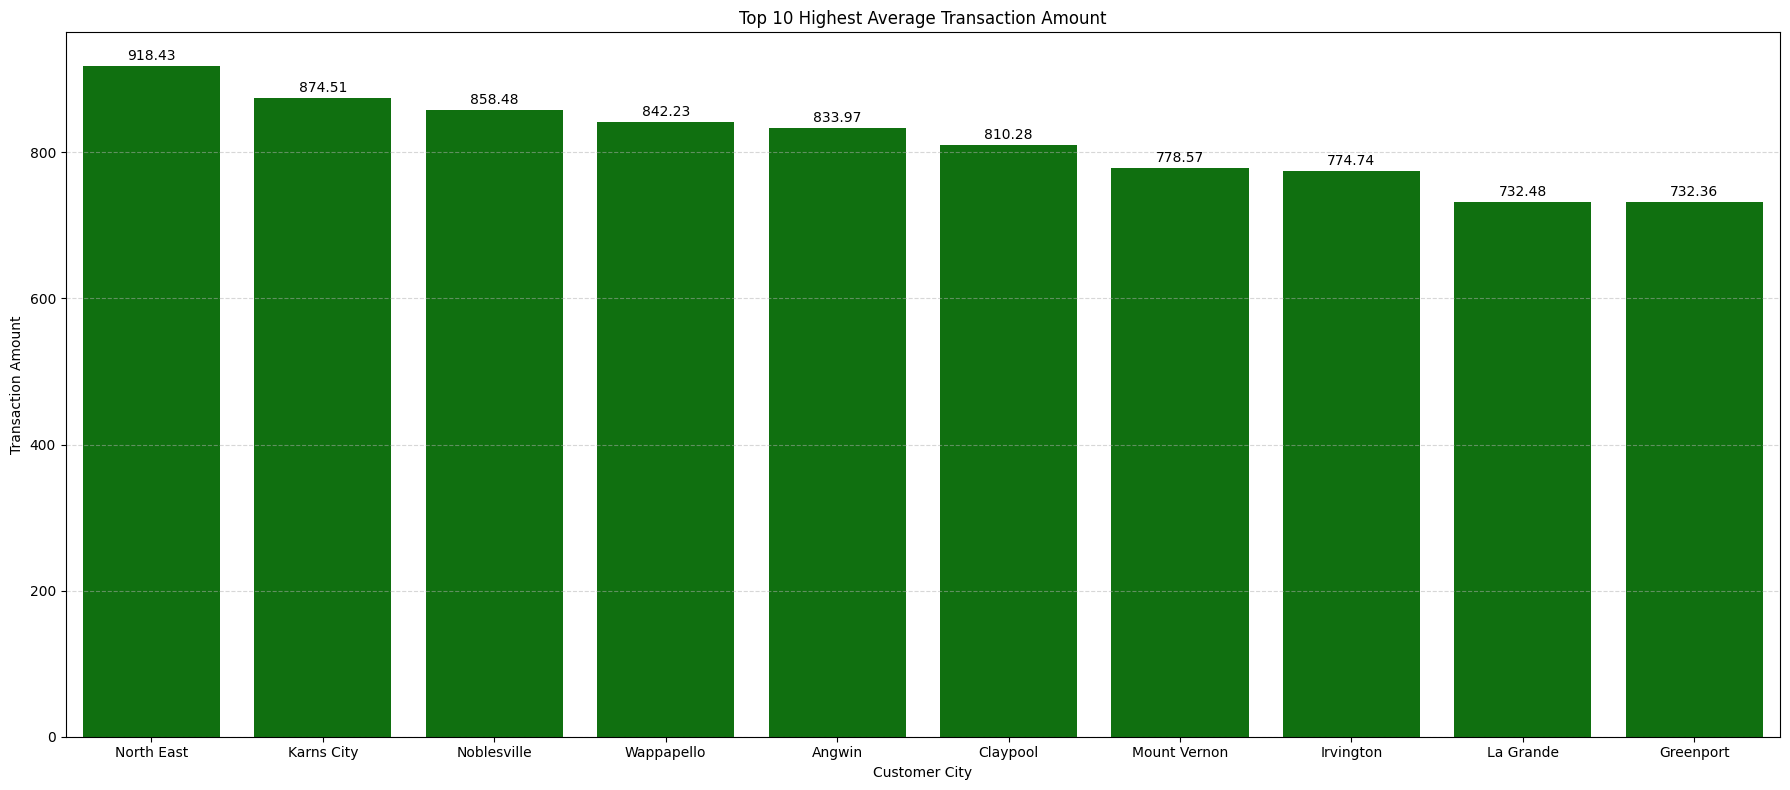

In [160]:
highest_avg_transaction_amount = (
  df.groupby("customer_city")["transaction_amount"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values(by = "transaction_amount", ascending = False)
    .head(10)
)

plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_avg_transaction_amount,
                 x = "customer_city",
                 y = "transaction_amount",
                 color = "green")
for container in ax.containers:
  ax.bar_label(
    container,
    fmt = "%.2f",
    padding = 2)

plt.title("Top 10 Highest Average Transaction Amount")
plt.xlabel("Customer City")
plt.ylabel("Transaction Amount")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Business Insight:

North East has the highest average transaction amount at $918.43, followed by Karns City at $874.51 and Noblesville at $858.48. The top 5 cities all have average transaction values above $830, indicating strong customer spending in these markets. These cities could be targeted with premium product offerings, upselling strategies, and personalized promotions to increase customer value, while lower-ranked cities can be analyzed for opportunities to improve average transaction size.

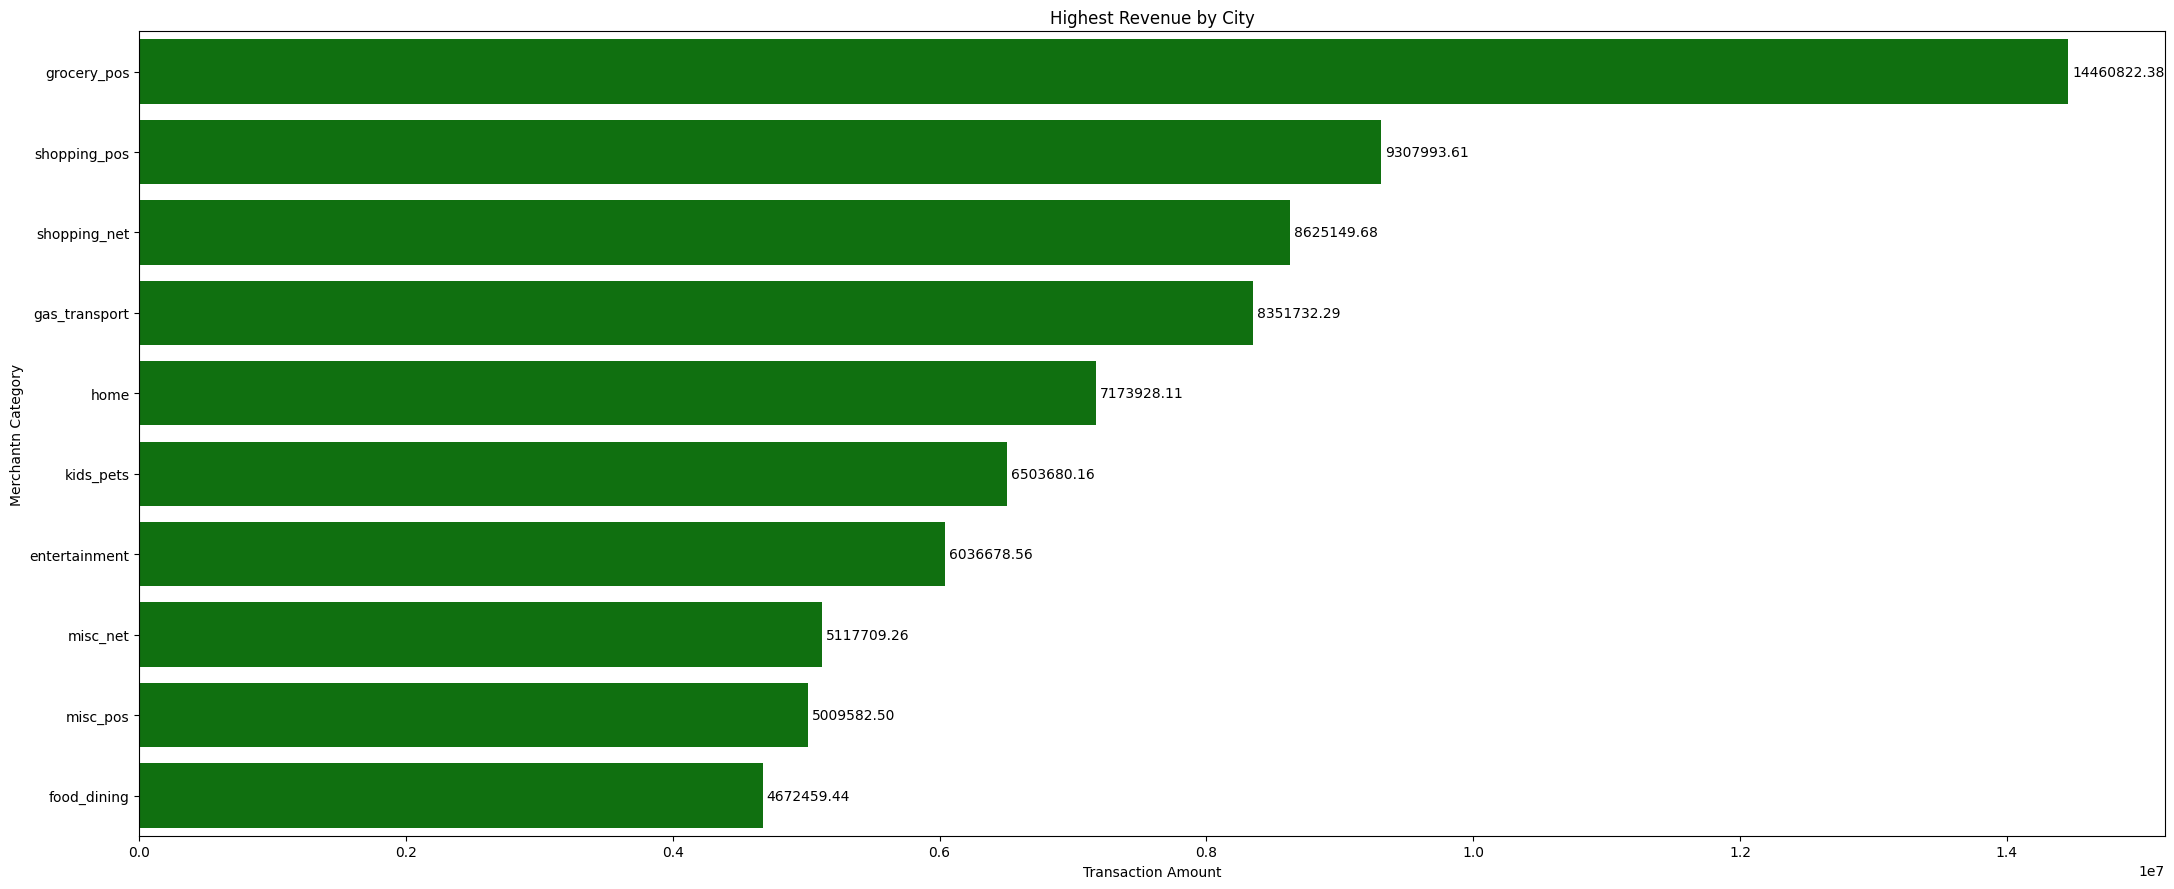

In [ ]:
highest_revenue_by_merchant = (
    df.groupby("merchant_category")["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "transaction_amount",ascending = False)
      .head(10)
)
plt.figure(figsize=(22,9))
ax = sns.barplot(data = highest_revenue_by_merchant,
                 x = "transaction_amount",
                 y = "merchant_category",
                 color = "green")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.2f",
        padding = 3
    )
plt.title("Top 10 Merchant Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

Business Insight:

Grocery POS generates the highest revenue at approximately $14.46M, followed by Shopping POS ($9.31M) and Shopping Net ($8.63M). These top merchant categories are the strongest revenue contributors and represent key areas for inventory planning, promotional campaigns, and customer retention strategies. Lower-performing categories such as Food & Dining ($4.67M) and Misc POS ($5.01M) may have opportunities for growth through targeted promotions and improved customer engagement.

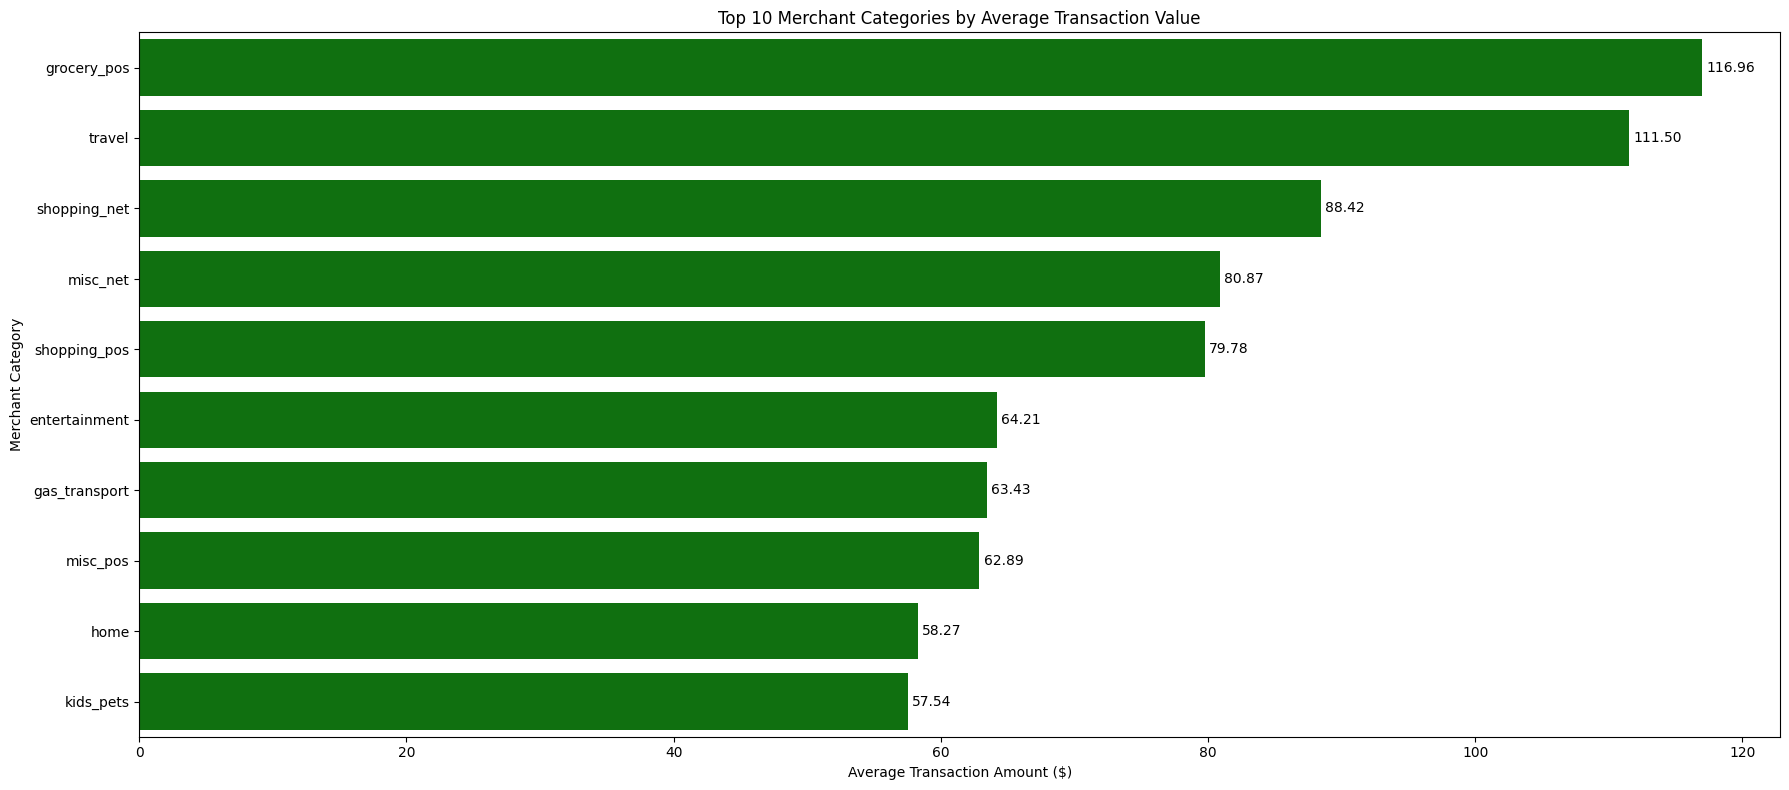

In [110]:
highest_avg_transaction_amount = (
    df.groupby("merchant_category")["transaction_amount"]
      .mean()
      .round(2)
      .reset_index()
      .sort_values(by= "transaction_amount", ascending = False)
      .head(10)
)
plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_avg_transaction_amount,
                x = "transaction_amount",
                y = "merchant_category",
                color = "green")
for container in ax.containers:
  ax.bar_label(
    container,
    fmt = "%.2f",
    padding = 3
)
plt.title("Top 10 Merchant Categories by Average Transaction Value")
plt.xlabel("Average Transaction Amount ($)")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()


Business Insight:

Grocery POS has the highest average transaction value at $116.96, followed by Travel ($111.50) and Shopping Net ($88.42). These categories indicate higher customer spending per transaction and could be strong opportunities for premium offerings, upselling, and personalized promotions. Lower-ranked categories such as Kids & Pets ($57.54) and Home ($58.27) have relatively lower average transaction values, suggesting opportunities to increase basket size through cross-selling, bundled offers, and targeted promotions.

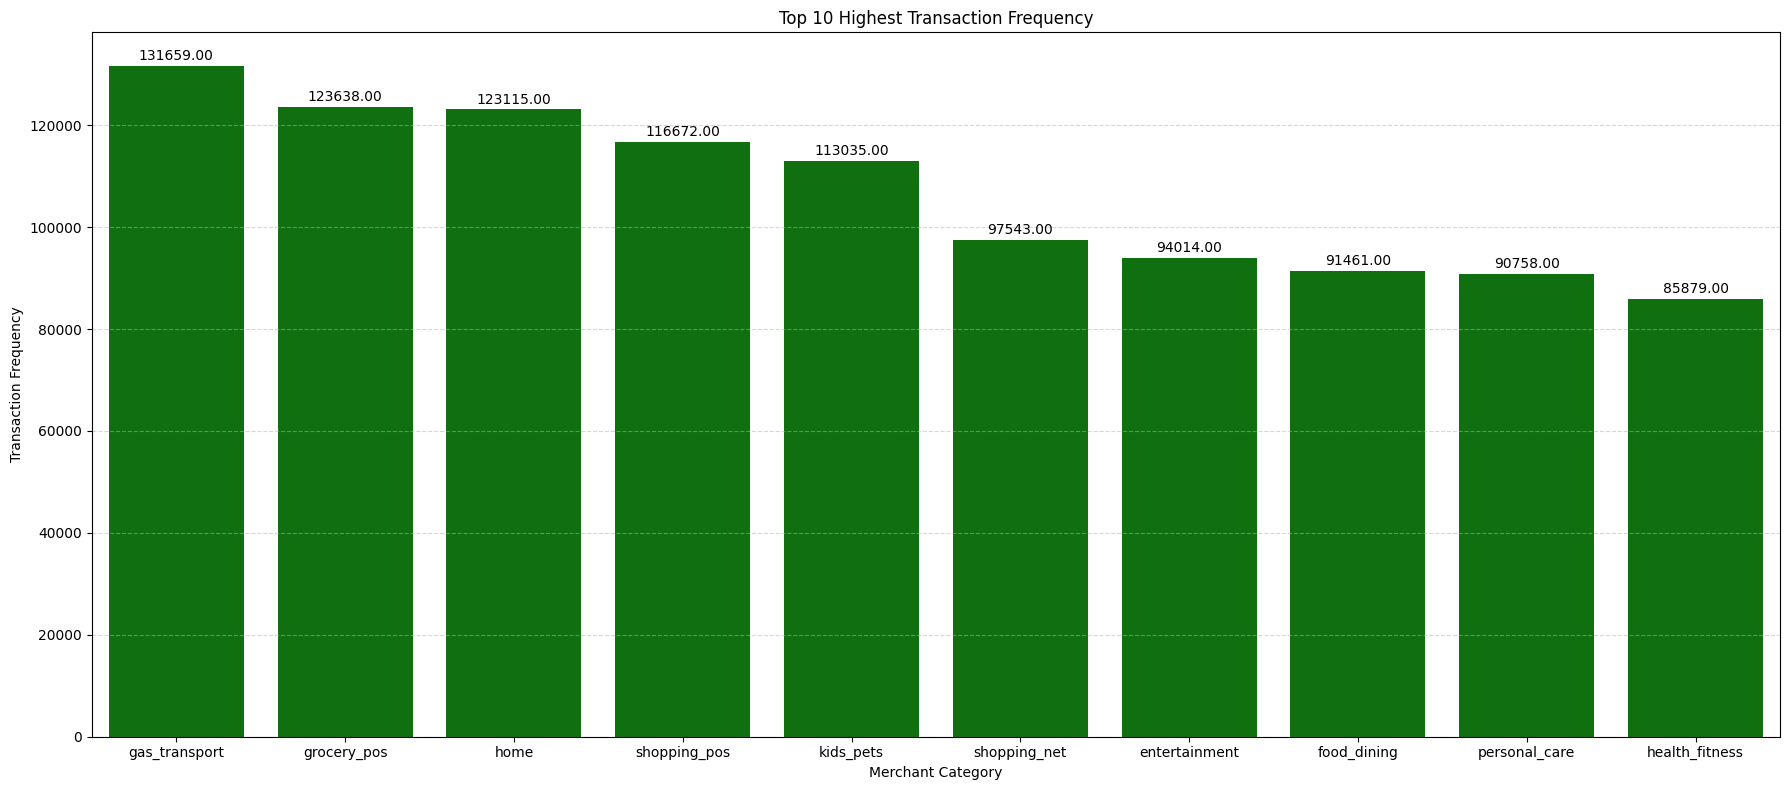

In [161]:
highest_transaction_frequency = (
  df.groupby("merchant_category")["transaction_amount"]
    .count()
    .reset_index()
    .sort_values(by = "transaction_amount", ascending = False)
    .head(10)
)

plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_transaction_frequency,
                 x = "merchant_category",
                 y = "transaction_amount",
                 color = "green")
for container in ax.containers:
  ax.bar_label(
    container,
    fmt = "%.2f",
    padding = 2)

plt.title("Top 10 Highest Transaction Frequency")
plt.xlabel("Merchant Category")
plt.ylabel("Transaction Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Gas Transport has the highest transaction frequency at 131,659 transactions, followed by Grocery POS (123,638) and Home (123,115). These merchant categories show the highest customer activity and represent key areas for customer retention, inventory availability, and targeted promotional campaigns. Categories such as Health & Fitness (85,879) and Personal Care (90,758) have comparatively lower transaction frequency, indicating potential opportunities to increase customer engagement and purchase frequency through cross-selling, promotions, and targeted marketing.

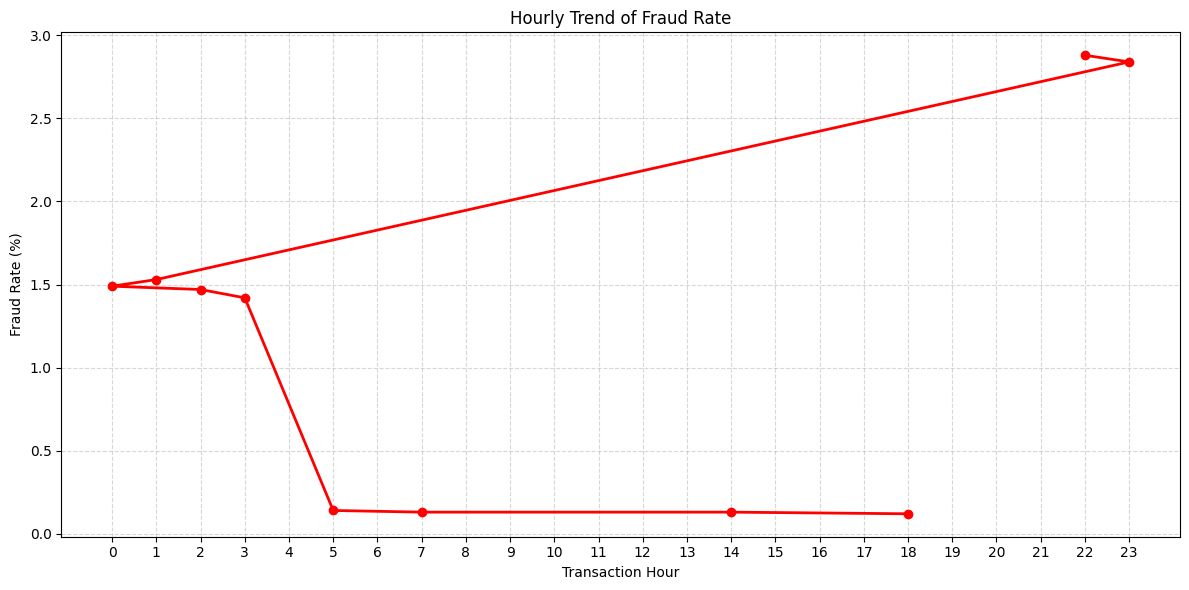

In [165]:
highest_fraud_rate = (
  df.groupby("transaction_hour")["fraud_flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .sort_values(by = "fraud_flag", ascending = False)
    .head(10)
)
plt.figure(figsize=(12,6))

plt.plot(
    highest_fraud_rate["transaction_hour"],
    highest_fraud_rate["fraud_flag"],
    marker="o",
    linewidth=2,
    color="red"
)
plt.title("Hourly Trend of Fraud Rate")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Fraud risk is highest during late-night hours, reaching approximately 2.88% at 22:00 and 2.84% at 23:00. In comparison, the fraud rate remains around 1.4–1.5% during 00:00–03:00 and drops to approximately 0.1–0.15% during several daytime hours. This pattern suggests that transactions made during late-night hours may require stronger fraud monitoring, additional verification, or real-time transaction alerts to reduce potential fraudulent activity.

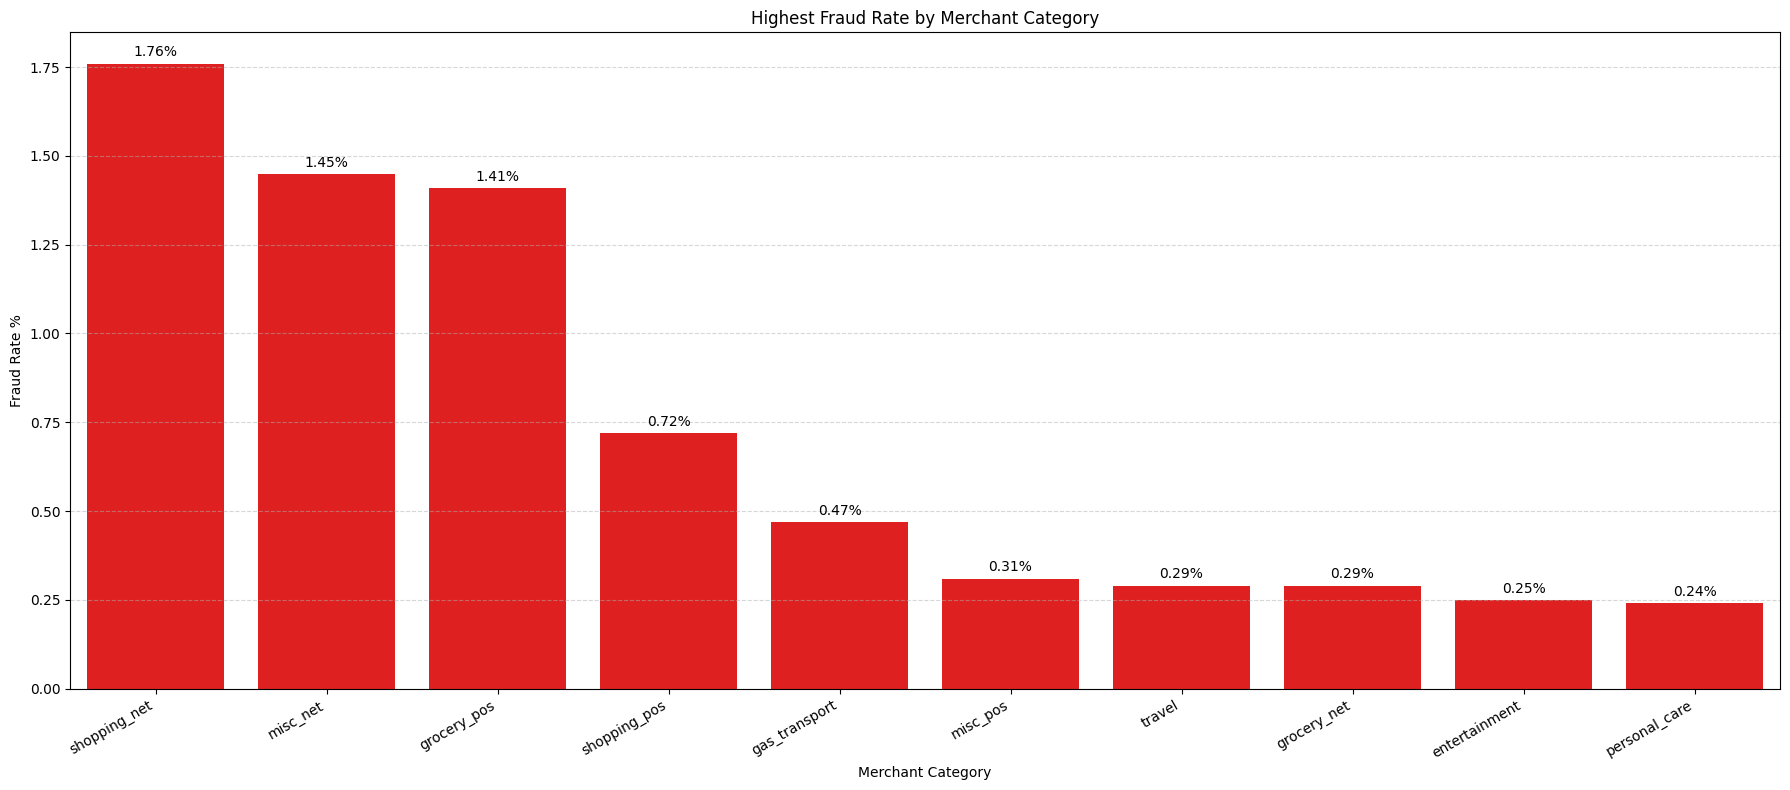

In [146]:
highest_fraud_rate_by_merchant = (
    df.groupby("merchant_category")["fraud_flag"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .sort_values(by = "fraud_flag",ascending = False)
      .head(10)
)
plt.figure(figsize=(18,8))
ax=sns.barplot(data = highest_fraud_rate_by_merchant,
                x = "merchant_category",
                y = "fraud_flag",
                color = "red")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.2f%%",
        padding = 3)

plt.title("Highest Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate %")
plt.xticks(rotation=30, ha="right")
plt.grid(axis = "y",linestyle = "--",alpha = 0.5)
plt.tight_layout()
plt.show()

Business Insight:

Shopping Net has the highest fraud rate at 1.76%, followed by Misc Net (1.45%) and Grocery POS (1.41%). These merchant categories show comparatively higher fraud exposure and may require stronger transaction monitoring, additional verification, and targeted fraud-detection measures. Categories such as Personal Care (0.24%), Entertainment (0.25%), and Travel (0.29%) have much lower fraud rates, suggesting relatively lower fraud exposure and providing a useful benchmark for comparing fraud-risk patterns across merchant categories.

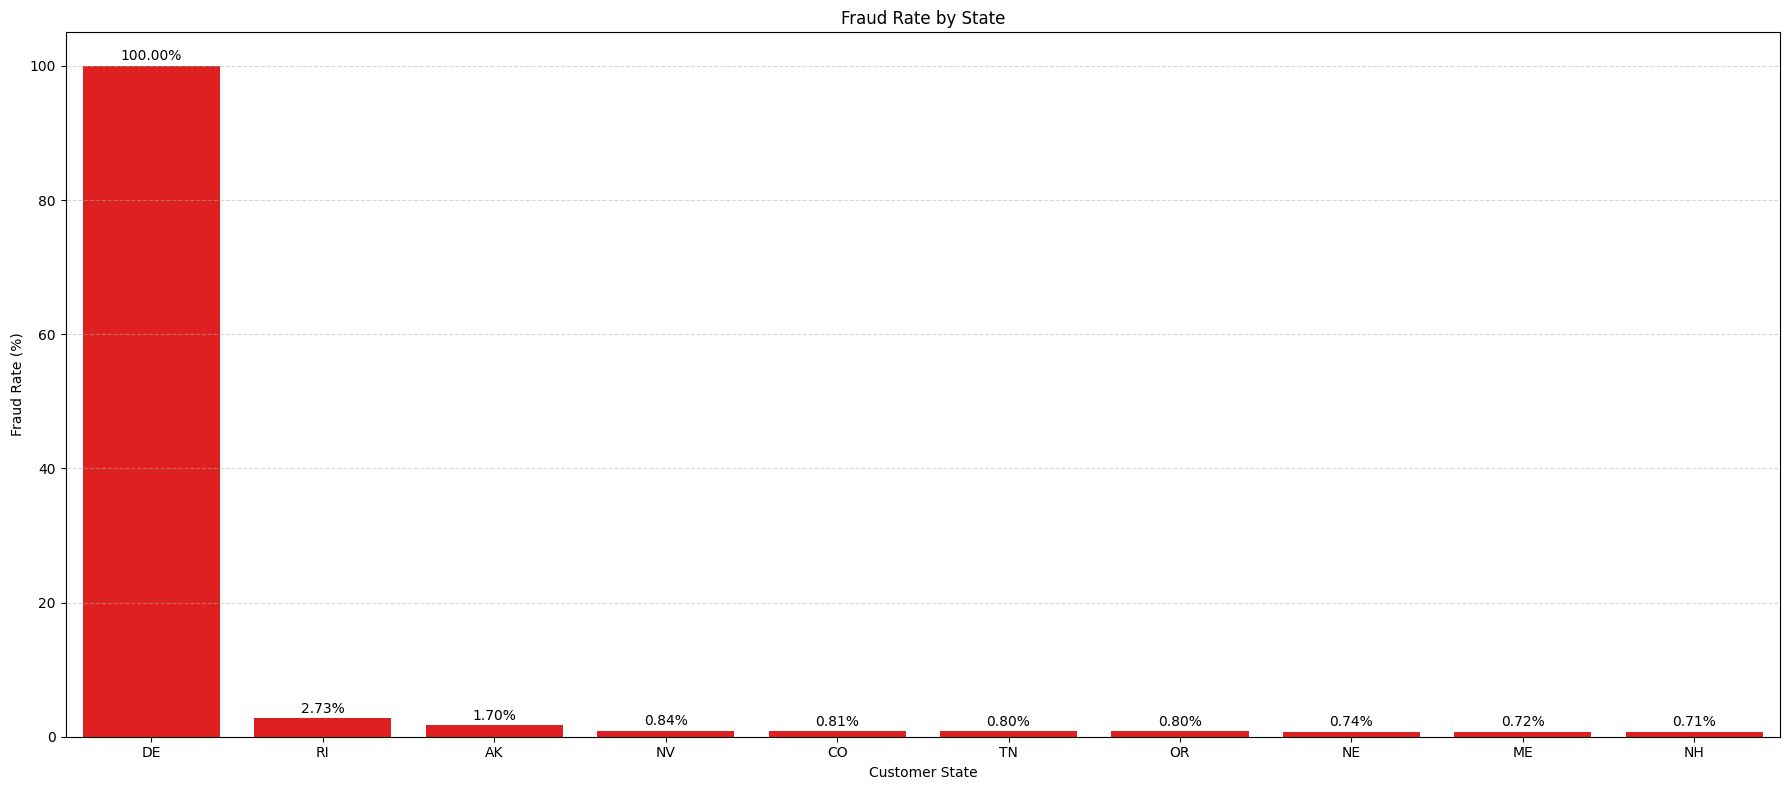

In [163]:
highest_fraud_rate = (
  df.groupby("customer_state")["fraud_flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .sort_values(by = "fraud_flag", ascending = False)
    .head(10)
)

plt.figure(figsize=(18,8))
ax = sns.barplot(data = highest_fraud_rate,
                 x = "customer_state",
                 y = "fraud_flag",
                 color = "red")
for container in ax.containers:
  ax.bar_label(
    container,
    fmt = "%.2f%%",
    padding = 2)

plt.title("Fraud Rate by State")
plt.xlabel("Customer State")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Business Insight:

Delaware (DE) has an unusually high fraud rate of 100%, while Rhode Island (RI) follows at 2.73% and Alaska (AK) at 1.70%. The extreme 100% rate for Delaware may indicate a very small number of transactions in the state, so it should be investigated further before drawing conclusions. The other high-rate states may benefit from additional transaction monitoring and fraud screening to identify potential risk patterns.

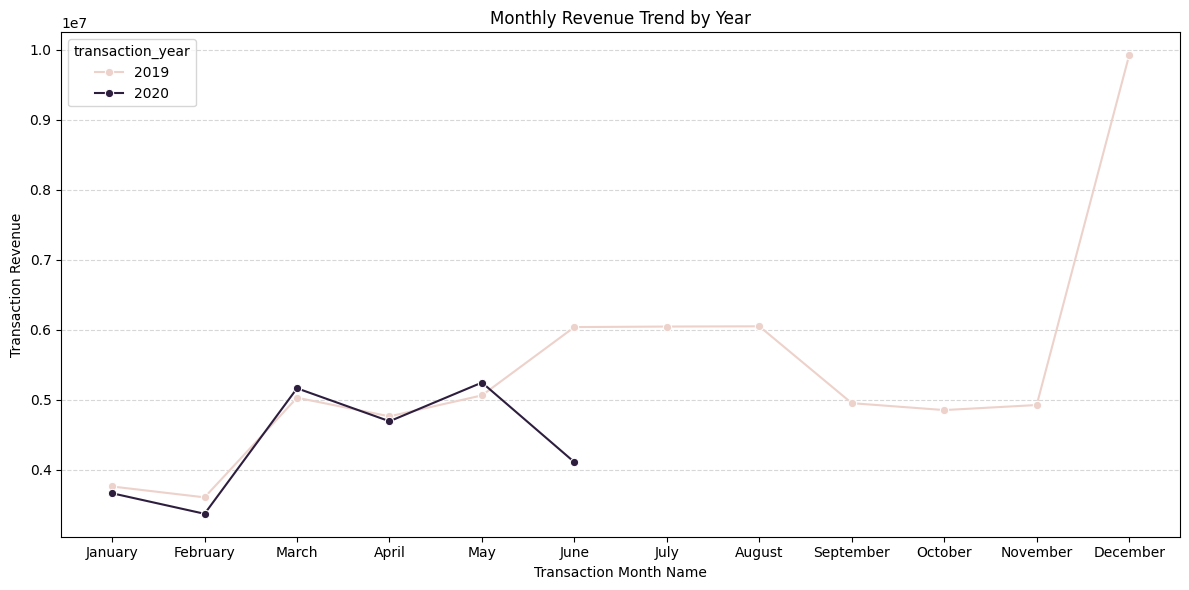

In [171]:
monthly_revenue = (
    df.groupby(["transaction_year","transaction_month_name"])["transaction_amount"]
      .sum()
      .round(2)
      .reset_index()
)
monthly_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"]

monthly_revenue["transaction_month_name"] = pd.Categorical(
    monthly_revenue["transaction_month_name"],categories = monthly_order,
    ordered = True)

monthly_revenue = monthly_revenue.sort_values(
    by = ["transaction_year","transaction_month_name"])

plt.figure(figsize=(12,6))
sns.lineplot(data = monthly_revenue,
              x = "transaction_month_name",
              y = "transaction_amount",
              hue = "transaction_year",
              marker = "o")
plt.title("Monthly Revenue Trend by Year")
plt.xlabel("Transaction Month Name")
plt.ylabel("Transaction Revenue")
plt.grid(axis = "y", linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()

Business Insight:

Revenue was relatively stable during the early months, but 2019 consistently generated higher monthly revenue than 2020 from June onward. The gap becomes especially noticeable in June, July, August, and September, while 2020 revenue declined sharply in June. This indicates a significant drop in revenue performance in 2020 and suggests the business should investigate factors such as changes in transaction volume, customer demand, merchant-category performance, or market conditions that may have contributed to the decline.

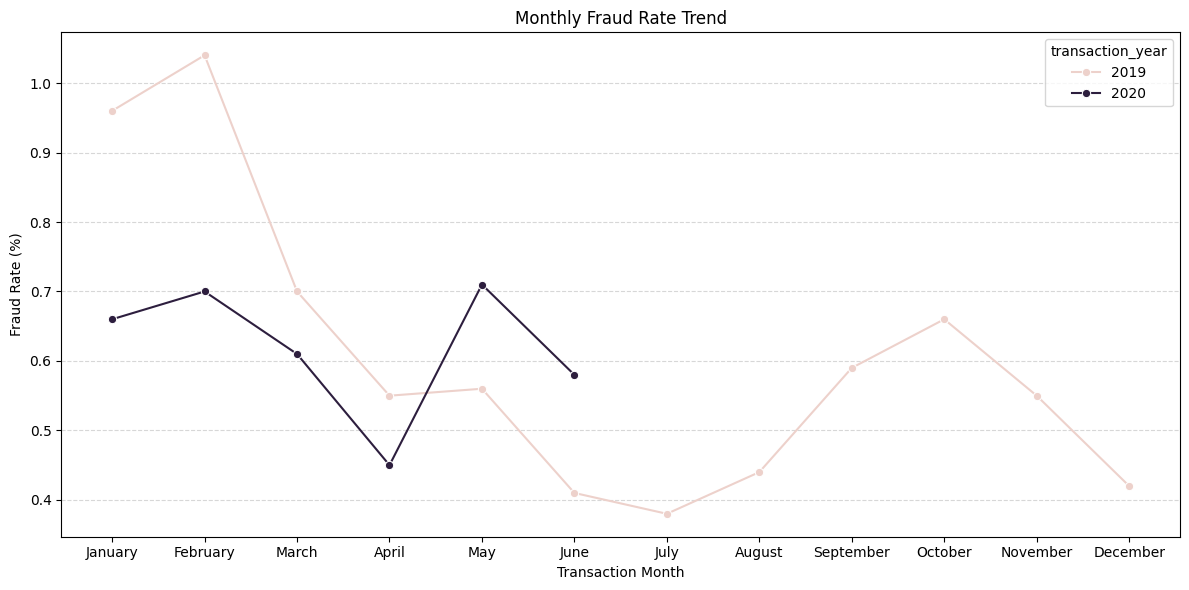

In [182]:
highest_fraud_rate = (
  df.groupby(["transaction_year","transaction_month_name"])["fraud_flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .sort_values(by = "fraud_flag", ascending = False)
)

month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]

highest_fraud_rate["transaction_month_name"] = pd.Categorical(
  highest_fraud_rate["transaction_month_name"],categories = month_order,ordered = True)

highest_fraud_rate = highest_fraud_rate.sort_values(by = ["transaction_year","transaction_month_name"])

plt.figure(figsize=(12,6))
sns.lineplot(data = highest_fraud_rate,
            x = "transaction_month_name",
            y = "fraud_flag",
            hue = "transaction_year",
            marker = "o")

plt.title("Monthly Fraud Rate Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Business Insight:

The monthly fraud rate fluctuated between 2019 and 2020, with the highest rate occurring in February 2019 at approximately 1.04%. In 2020, fraud peaked at around 0.71% in May, while the rate remained lower during April and June. Overall, the variation across months indicates that fraud risk is not consistent throughout the year, suggesting the business should strengthen monitoring during higher-risk periods and investigate the factors behind monthly fraud-rate spikes.

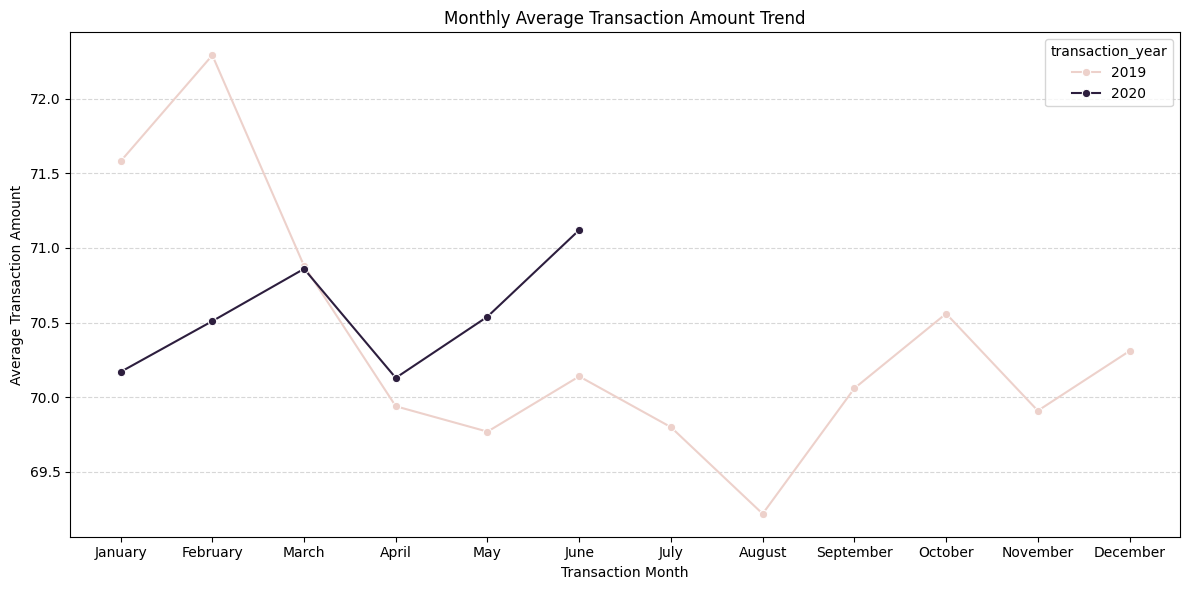

In [187]:
highest_avg_transaction = (
  df.groupby(["transaction_year","transaction_month_name"])["transaction_amount"]
    .mean()
    .round(2)
    .reset_index()
)

month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]

highest_avg_transaction ["transaction_month_name"] = pd. Categorical(
  highest_avg_transaction["transaction_month_name"],categories = month_order,ordered = True)

highest_avg_transaction  = highest_avg_transaction.sort_values(by = ["transaction_year","transaction_month_name"])

plt.figure(figsize=(12,6))
sns.lineplot(data = highest_avg_transaction,
              x = "transaction_month_name",
              y = "transaction_amount",
              hue = "transaction_year",
              marker = "o")
plt.title("Monthly Average Transaction Amount Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Average Transaction Amount")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Business Insight:

The average transaction amount remained relatively stable across 2019 and 2020, generally ranging between $69 and $72. In 2019, the average transaction value peaked at approximately $72.29 in February, while 2020 reached its highest level at around $71.12 in June. The overall stability suggests that changes in revenue during this period were likely influenced more by transaction volume or customer activity than by major changes in average transaction value.